
stargazers_count summary by RQ1:
  RQ1=1  n=1542  median=205.50  IQR=(93.25, 628.50)
  RQ1=0  n=2976  median=226.00  IQR=(101.00, 665.00)

repo_age (years) summary by RQ1:
  RQ1=1  n=1542  median=5.77  IQR=(3.57, 8.37)
  RQ1=0  n=2976  median=5.68  IQR=(3.33, 8.76)

contributors summary by RQ1:
  RQ1=1  n=1542  median=5.00  IQR=(2.00, 16.00)
  RQ1=0  n=2976  median=5.00  IQR=(2.00, 16.00)

pull_requests summary by RQ1:
  RQ1=1  n=1542  median=27.00  IQR=(5.00, 178.00)
  RQ1=0  n=2976  median=26.00  IQR=(5.00, 110.00)

size summary by RQ1:
  RQ1=1  n=1542  median=10749.50  IQR=(2587.00, 47485.00)
  RQ1=0  n=2976  median=9842.50  IQR=(2085.50, 40886.25)

forks_count summary by RQ1:
  RQ1=1  n=1542  median=33.50  IQR=(15.00, 106.00)
  RQ1=0  n=2976  median=40.00  IQR=(17.00, 107.00)

commits_GitAPI summary by RQ1:
  RQ1=1  n=1542  median=292.50  IQR=(82.00, 1053.00)
  RQ1=0  n=2976  median=241.00  IQR=(81.00, 793.50)


C:\Users\gilla\AppData\Local\Temp\ipykernel_5352\3470000834.py:180: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\gilla\AppData\Local\Temp\ipykernel_5352\3470000834.py:180: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\gilla\AppData\Local\Temp\ipykernel_5352\3470000834.py:180: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\gilla\AppData\Local\Temp\ipykernel_5352\3470000834.py:180: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxpl

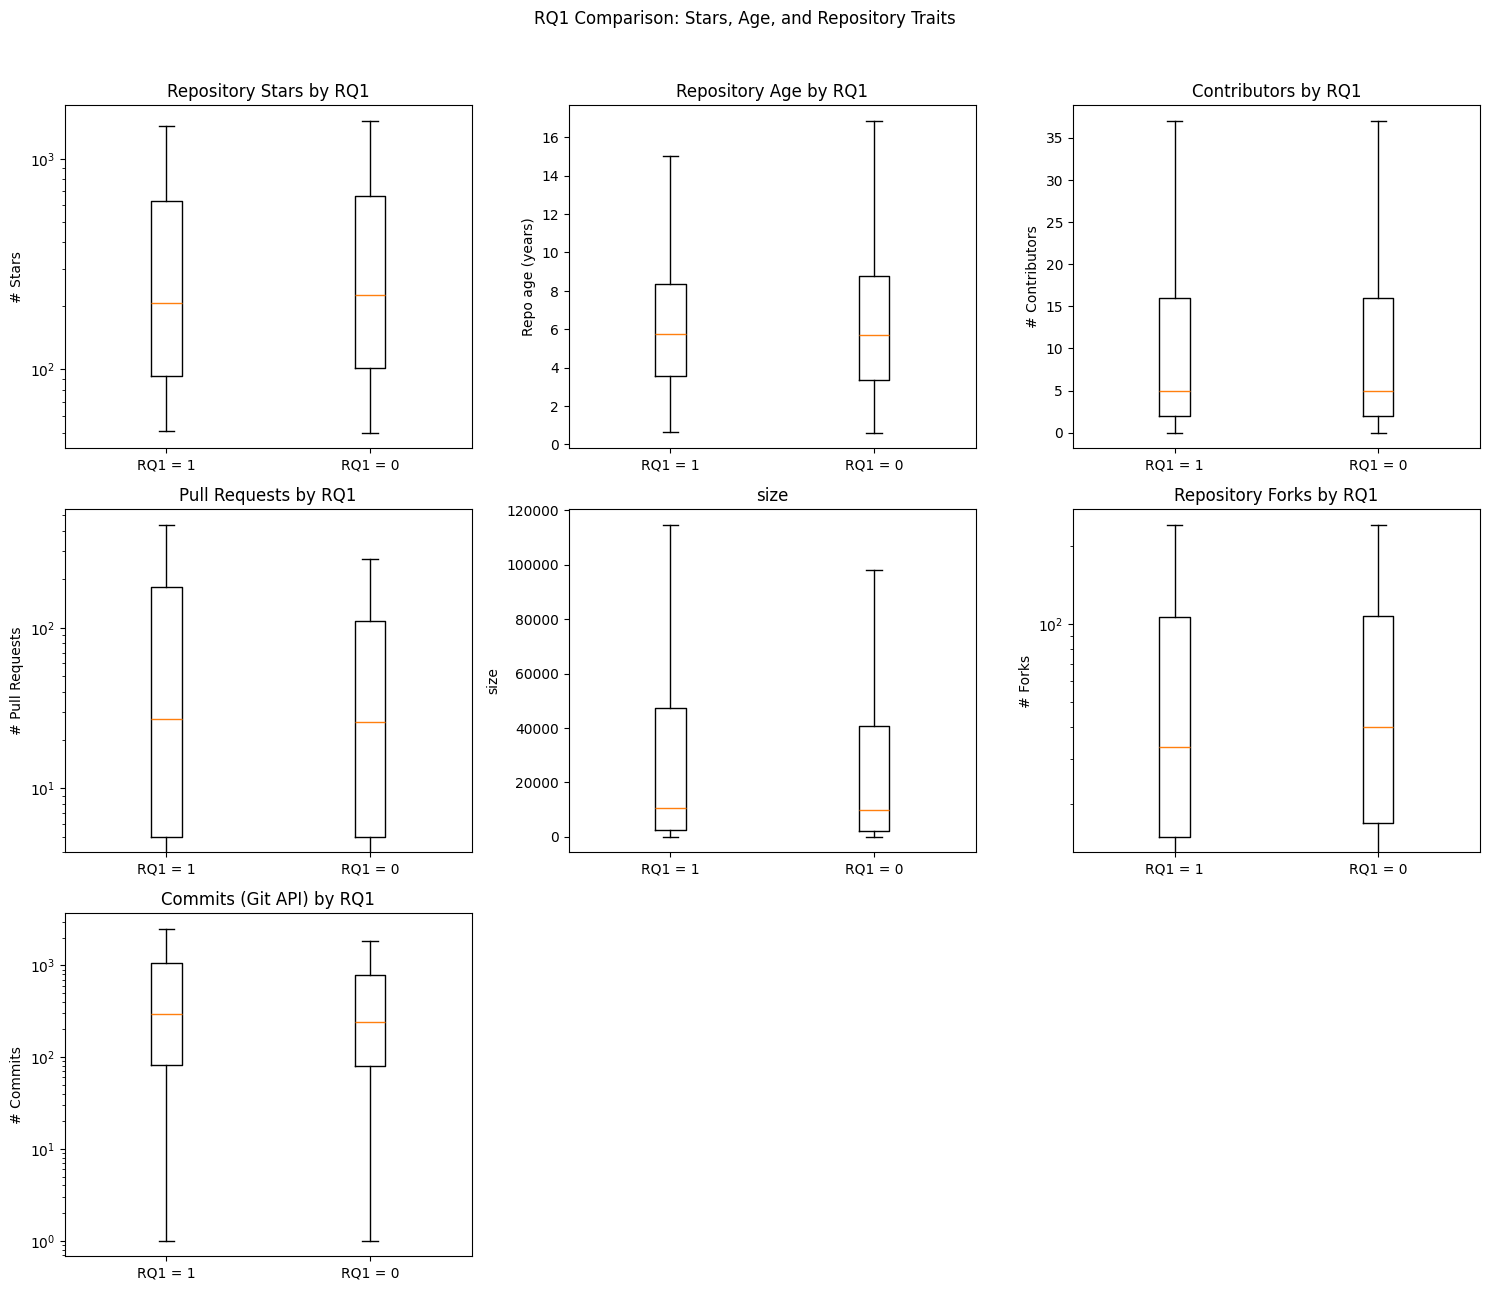


Saved: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ1\one_figure_boxplots_RQ1_all_metrics.png


In [7]:
# -*- coding: utf-8 -*-
"""
One-figure boxplots by RQ1 (Adopted vs Non-adopted) for:
  - stargazers_count (required)
  - repo_age (required; auto-converts days -> years if values look like days)
  - contributors
  - pull_requests
  - size
  - forks_count
  - commits_GitAPI

Input:
  C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ1\3.2_Total_Repo_with_RQ1.csv

Output:
  one_figure_boxplots_RQ1_all_metrics.png
"""

from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- CONFIG ----------------
CSV_PATH = r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ1\3.2_Total_Repo_with_RQ1.csv"

# RQ1 candidates (will be coerced to 0/1)
RQ1_CANDIDATES = ["RQ1_Adopted_int", "RQ1_Adopted", "RQ1", "rq1"]

# Metrics to plot (order matters in layout)
# 'stargazers_count' and 'repo_age' are required. Others are optional; missing ones are skipped.
METRICS = [
    "stargazers_count",   # required
    "repo_age",           # required (days or years)
    "contributors",
    "pull_requests",
    "size",
    "forks_count",
    "commits_GitAPI",
]

# Use log scale for these (skewed counts)
LOG_SCALE_FOR = {"stargazers_count", "forks_count", "pull_requests", "commits_GitAPI"}

# Hide extreme outliers in boxplots? (visual clarity)
HIDE_OUTLIERS = True

# Grid layout (auto if None)
N_COLS = 3  # 3 columns looks good for up to ~9 metrics
# ---------------------------------------

# ---- load
csv_path = Path(CSV_PATH)
df = pd.read_csv(csv_path, encoding="utf-8-sig")

# ---- helpers
def pick_col(frame, candidates):
    """Return the first column from candidates that exists in frame (case-insensitive)."""
    lc = {c.lower(): c for c in frame.columns}
    for cand in candidates:
        if cand.lower() in lc:
            return lc[cand.lower()]
    return None

def to_01(series: pd.Series) -> pd.Series:
    """Coerce to 0/1 ints from bool/numeric/string tokens."""
    s = series
    if s.dtype == bool:
        return s.astype(int)
    if pd.api.types.is_numeric_dtype(s):
        return (pd.to_numeric(s, errors="coerce").fillna(0) > 0).astype(int)
    t = s.astype(str).str.strip().str.lower()
    token_map = {
        "1":1,"true":1,"yes":1,"y":1,"t":1,"on":1,
        "0":0,"false":0,"no":0,"n":0,"f":0,"off":0,"":0,"none":0,"null":0,"na":0,"nan":0
    }
    mapped = t.map(token_map)
    num = pd.to_numeric(t.str.replace(r"[^0-9\.\-]+", "", regex=True), errors="coerce")
    num01 = (num.fillna(0) > 0).astype(int)
    return mapped.where(mapped.notna(), num01).fillna(0).astype(int)

def to_num(series: pd.Series) -> pd.Series:
    """Coerce to numeric (NaN for non-numeric), strips commas if present."""
    return pd.to_numeric(series.astype(str).str.replace(",", "", regex=False), errors="coerce")

def summarize(name, s_true, s_false):
    def stats(x):
        x = x.dropna().values
        if x.size == 0:
            return {"n":0,"median":np.nan,"p25":np.nan,"p75":np.nan}
        return {
            "n": x.size,
            "median": float(np.nanmedian(x)),
            "p25": float(np.nanpercentile(x, 25)),
            "p75": float(np.nanpercentile(x, 75)),
        }
    st, sf = stats(s_true), stats(s_false)
    print(f"\n{name} summary by RQ1:")
    print(f"  RQ1=1  n={st['n']:<5} median={st['median']:.2f}  IQR=({st['p25']:.2f}, {st['p75']:.2f})")
    print(f"  RQ1=0  n={sf['n']:<5} median={sf['median']:.2f}  IQR=({sf['p25']:.2f}, {sf['p75']:.2f})")

# ---- detect RQ1
rq1_col = pick_col(df, RQ1_CANDIDATES)
if not rq1_col:
    raise KeyError(f"Could not find RQ1 column. Expected one of: {RQ1_CANDIDATES}")
rq1 = to_01(df[rq1_col])

# ---- enforce required metrics
missing_required = [m for m in ["stargazers_count", "repo_age"] if m not in df.columns]
if missing_required:
    raise KeyError(f"Missing required column(s): {missing_required}. "
                   f"'stargazers_count' and 'repo_age' must be present.")

# ---- prepare metrics (coerce numeric; special handling for repo_age)
prepared = {}
for m in METRICS:
    if m not in df.columns:
        print(f"Skipping missing column: {m}")
        continue
    s = to_num(df[m])
    if m == "repo_age":
        # heuristic: convert days -> years if max looks like days (e.g., > 1000)
        max_age = s.dropna().max()
        if pd.notna(max_age) and max_age > 1000:
            s = s / 365.25
        prepared[m] = s
    else:
        prepared[m] = s

# ---- masks
mask_true, mask_false = rq1.eq(1), rq1.eq(0)

# ---- print summaries
for m, s in prepared.items():
    # label 'repo_age' with units if converted
    label = m if m != "repo_age" else ("repo_age (years)" if s.dropna().max() and s.dropna().max() < 1000 else "repo_age (years)")
    summarize(label, s[mask_true], s[mask_false])

# ---- layout
metrics_present = list(prepared.keys())
n = len(metrics_present)
if n == 0:
    raise RuntimeError("No metrics available to plot.")
n_cols = N_COLS or min(3, n)
n_rows = math.ceil(n / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4.2*n_rows))
if isinstance(axes, np.ndarray):
    axes = axes.flatten()
else:
    axes = [axes]

# ---- draw each metric
for idx, m in enumerate(metrics_present):
    ax = axes[idx]
    s = prepared[m]
    # Human-friendly title/label
    title = m
    y_label = m
    if m == "repo_age":
        title = "Repository Age by RQ1"
        y_label = "Repo age (years)"
    elif m == "stargazers_count":
        title = "Repository Stars by RQ1"
        y_label = "# Stars"
    elif m == "forks_count":
        title = "Repository Forks by RQ1"
        y_label = "# Forks"
    elif m == "pull_requests":
        title = "Pull Requests by RQ1"
        y_label = "# Pull Requests"
    elif m == "contributors":
        title = "Contributors by RQ1"
        y_label = "# Contributors"
    elif m == "commits_GitAPI":
        title = "Commits (Git API) by RQ1"
        y_label = "# Commits"

    ax.boxplot(
        [s[mask_true].dropna().values, s[mask_false].dropna().values],
        labels=["RQ1 = 1", "RQ1 = 0"],
        showfliers=not HIDE_OUTLIERS
    )
    ax.set_title(title)
    ax.set_ylabel(y_label)
    if m in LOG_SCALE_FOR:
        ax.set_yscale("log")

# Hide any unused axes
for j in range(idx+1, len(axes)):
    axes[j].axis("off")

fig.suptitle("RQ1 Comparison: Stars, Age, and Repository Traits", y=1.02)
plt.tight_layout()
out_path = csv_path.with_name("one_figure_boxplots_RQ1_all_metrics.png")
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"\nSaved: {out_path}")


In [9]:
# -*- coding: utf-8 -*-
"""
Summaries for RQ1 groups (True vs False) across repo metrics.

Input:
  C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ1\3.2_Total_Repo_with_RQ1.csv

Outputs:
  RQ1_true_summary_table.csv
  RQ1_false_summary_table.csv
  RQ1_true_false_comparison_table.csv
"""

from pathlib import Path
import numpy as np
import pandas as pd

# -------- Paths --------
CSV_PATH = r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ1\3.2_Total_Repo_with_RQ1.csv"

# -------- Column names --------
# RQ1 will be detected from these candidates (first match wins)
RQ1_CANDIDATES = ["RQ1_Adopted_int", "RQ1_Adopted", "RQ1", "rq1"]

# Metrics to report (missing ones are skipped gracefully)
METRICS = [
    "stargazers_count",
    "repo_age",
    "contributors",
    "pull_requests",
    "size",
    "forks_count",
    "commits_GitAPI",
]

# If you KNOW repo_age is in days, set this True; if in years, set False.
# None = auto-detect (converts to years if max > 1000).
FORCE_AGE_DAYS = None


# -------- Helpers --------
def pick_col(frame, candidates):
    """Return the first column from candidates that exists in frame (case-insensitive)."""
    lc = {c.lower(): c for c in frame.columns}
    for cand in candidates:
        if cand.lower() in lc:
            return lc[cand.lower()]
    return None

def to_01(series: pd.Series) -> pd.Series:
    """Coerce to 0/1 ints from bool/numeric/string tokens."""
    s = series
    if s.dtype == bool:
        return s.astype(int)
    if pd.api.types.is_numeric_dtype(s):
        return (pd.to_numeric(s, errors="coerce").fillna(0) > 0).astype(int)
    t = s.astype(str).str.strip().str.lower()
    token_map = {
        "1":1,"true":1,"yes":1,"y":1,"t":1,"on":1,
        "0":0,"false":0,"no":0,"n":0,"f":0,"off":0,"":0,"none":0,"null":0,"na":0,"nan":0
    }
    mapped = t.map(token_map)
    num = pd.to_numeric(t.str.replace(r"[^0-9\.\-]+", "", regex=True), errors="coerce")
    num01 = (num.fillna(0) > 0).astype(int)
    return mapped.where(mapped.notna(), num01).fillna(0).astype(int)

def to_num(series: pd.Series) -> pd.Series:
    """Coerce to numeric (NaN for non-numeric), strips commas if present."""
    return pd.to_numeric(series.astype(str).str.replace(",", "", regex=False), errors="coerce")

def summarize_series(s: pd.Series) -> dict:
    """Return n, min, Q1, median, mean, Q3, max for a numeric series."""
    x = s.dropna().values
    if x.size == 0:
        return {"n": 0, "min": np.nan, "q1": np.nan, "median": np.nan, "mean": np.nan, "q3": np.nan, "max": np.nan}
    return {
        "n": int(x.size),
        "min": float(np.nanmin(x)),
        "q1": float(np.nanpercentile(x, 25)),
        "median": float(np.nanmedian(x)),
        "mean": float(np.nanmean(x)),
        "q3": float(np.nanpercentile(x, 75)),
        "max": float(np.nanmax(x)),
    }

def prep_metric(series: pd.Series, name: str) -> tuple[str, pd.Series]:
    """Prepare a metric series; convert repo_age to years when appropriate and return (label, numeric_series)."""
    s = to_num(series)
    label = name
    if name == "repo_age":
        if FORCE_AGE_DAYS is True:
            s = s / 365.25
            label = "repo_age (years)"
        elif FORCE_AGE_DAYS is False:
            label = "repo_age (years)"  # assume already years; keep label consistent
        else:
            max_age = s.dropna().max()
            if pd.notna(max_age) and max_age > 1000:
                s = s / 365.25
            label = "repo_age (years)"
    return label, s

def build_summary(df_subset: pd.DataFrame) -> pd.DataFrame:
    """Build summary table for all metrics present in df_subset."""
    rows = []
    for metric in METRICS:
        if metric not in df_subset.columns:
            # Skip missing columns
            continue
        label, s = prep_metric(df_subset[metric], metric)
        stats = summarize_series(s)
        rows.append({
            "Metric": label,
            "n": stats["n"],
            "min": stats["min"],
            "Q1": stats["q1"],
            "median": stats["median"],
            "mean": stats["mean"],
            "Q3": stats["q3"],
            "max": stats["max"],
        })
    out = pd.DataFrame(rows, columns=["Metric", "n", "min", "Q1", "median", "mean", "Q3", "max"])
    for col in ["min", "Q1", "median", "mean", "Q3", "max"]:
        out[col] = out[col].round(2)
    return out


# -------- Load data --------
csv_path = Path(CSV_PATH)
df = pd.read_csv(csv_path, encoding="utf-8-sig")

# Detect RQ1 column
rq1_col = pick_col(df, RQ1_CANDIDATES)
if not rq1_col:
    raise KeyError(f"Could not find RQ1 column. Expected one of: {RQ1_CANDIDATES}")
rq1 = to_01(df[rq1_col])

# Split groups
df_true  = df.loc[rq1.eq(1)].copy()
df_false = df.loc[rq1.eq(0)].copy()

# Build summaries
summary_true  = build_summary(df_true)
summary_false = build_summary(df_false)

# Save individual tables
out_true  = csv_path.with_name("RQ1_true_summary_table.csv")
out_false = csv_path.with_name("RQ1_false_summary_table.csv")
summary_true.to_csv(out_true, index=False, encoding="utf-8-sig")
summary_false.to_csv(out_false, index=False, encoding="utf-8-sig")

# Build a side-by-side comparison table on 'Metric'
comp = summary_true.set_index("Metric").join(
    summary_false.set_index("Metric"),
    lsuffix="_RQ1=1",
    rsuffix="_RQ1=0",
    how="outer"
).reset_index()

out_comp = csv_path.with_name("RQ1_true_false_comparison_table.csv")
comp.to_csv(out_comp, index=False, encoding="utf-8-sig")

# Print to console
print("\n=== RQ1 = 1 (Adopters) ===")
print(summary_true.to_string(index=False))
print("\n=== RQ1 = 0 (Non-adopters) ===")
print(summary_false.to_string(index=False))
print("\n=== Side-by-side comparison ===")
print(comp.to_string(index=False))

print(f"\nSaved:\n  {out_true}\n  {out_false}\n  {out_comp}")



=== RQ1 = 1 (Adopters) ===
          Metric    n   min      Q1   median     mean       Q3        max
stargazers_count 1542 51.00   93.25   205.50  1044.48   628.50   52466.00
repo_age (years) 1542  0.62    3.57     5.77     6.11     8.37      16.59
    contributors 1542  0.00    2.00     5.00    20.49    16.00     439.00
   pull_requests 1542  0.00    5.00    27.00   315.16   178.00   20402.00
            size 1542 36.00 2587.00 10749.50 67578.56 47485.00 3398335.00
     forks_count 1542  0.00   15.00    33.50   168.80   106.00   11543.00
  commits_GitAPI 1542  1.00   82.00   292.50  1326.52  1053.00   78315.00

=== RQ1 = 0 (Non-adopters) ===
          Metric    n   min      Q1  median     mean       Q3        max
stargazers_count 2976 50.00  101.00  226.00  1072.97   665.00   99740.00
repo_age (years) 2976  0.61    3.33    5.68     6.12     8.76      16.85
    contributors 2976  0.00    2.00    5.00    20.11    16.00     460.00
   pull_requests 2976  0.00    5.00   26.00   243.63   1